In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def second_half(arr):
     return arr[len(arr)//2:]

def dur_to_fps(durs):
    return [1/dur for dur in durs]

def sma_fix(durs, n):
    return durs;

def sma_dyn(times, durs, secs):
    ret = []
    queue = []
    prev = times[0]
    for i in range(0, len(times)):
        queue.append([times[i], durs[i]])
        cur = times[i]
        while queue[0][0] + secs < cur:
            queue.pop(0)
        fps = 1/(sum([dur for [time, dur] in queue])/len(queue))
        ret.append(fps)
        prev = cur
    return ret

def sma_fix(durs, n):
    ret = []
    queue = []
    prev = times[0]
    for dur in durs:
        queue.append(dur)
        if len(queue) > n:
            queue.pop(0)
        fps = 1/(sum(queue)/len(queue))
        ret.append(fps)
    return ret

def ema_dyn(durs, secs):
    t = secs/2
    cur = durs[0]
    time = times[0]
    ret = [cur]
    for dur in durs[1:]:
        cur = (dur*dur+cur*t)/(t+dur)
        ret.append(cur)

    return dur_to_fps(ret)

def ema_fix(durs, n):
    alpha = 2/(n+1)
    cur = durs[0]
    time = times[0]
    ret = [cur]
    for dur in durs[1:]:
        cur = alpha*dur + (1-alpha)*cur
        ret.append(cur)

    return dur_to_fps(ret)

In [3]:
cap1_path = 'CapFrameX-PioneerGame.exe-2026-04-25T19715.json'
cap2_path = 'CapFrameX-PioneerGame.exe-2026-04-25T19847.json'
cap3_path = 'CapFrameX-PioneerGame.exe-2026-04-25T191235.json'

In [4]:
with open(cap1_path, 'r') as file:
    data = json.load(file)

In [5]:
frame_times = data['Runs'][0]['CaptureData']['TimeInSeconds']
frame_durs = [ms/1000 if ms > 0 else 0 for ms in data['Runs'][0]['CaptureData']['MsBetweenPresents']]

In [6]:
times =  [s - 55 for s in frame_times if s > 55]
fps_raw = dur_to_fps(frame_durs[-len(times):])
fps_sma_fix_60 = sma_fix(frame_durs, 60)[-len(times):]
fps_sma_fix_300 = sma_fix(frame_durs, 300)[-len(times):]
fps_sma_dyn_1s = sma_dyn(frame_times, frame_durs, 1)[-len(times):]
fps_sma_dyn_5s = sma_dyn(frame_times, frame_durs, 5)[-len(times):]
fps_ema_fix_60 = ema_fix(frame_durs, 60)[-len(times):]
fps_ema_fix_300 = ema_fix(frame_durs, 300)[-len(times):]
fps_ema_dyn_1s = ema_dyn(frame_durs, 1)[-len(times):]
fps_ema_dyn_5s = ema_dyn(frame_durs, 5)[-len(times):]

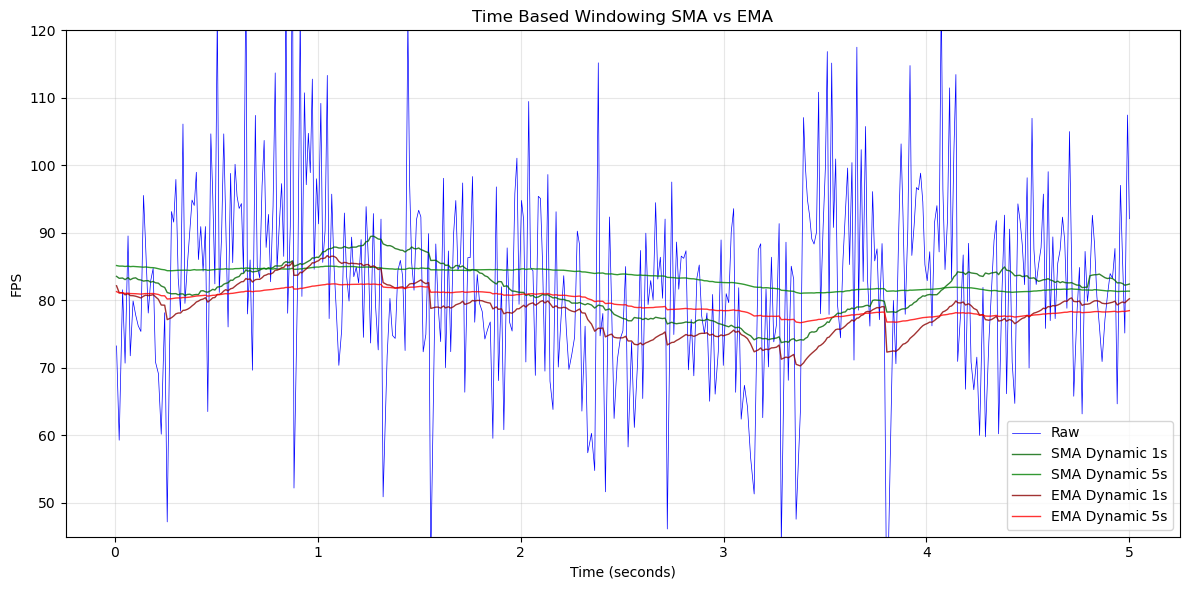

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(times, fps_raw, 'b-', label="Raw", linewidth=0.5)
plt.plot(times, fps_sma_dyn_1s, 'darkgreen', label="SMA Dynamic 1s", linewidth=1, alpha=0.8)
plt.plot(times, fps_sma_dyn_5s, 'green', label="SMA Dynamic 5s", linewidth=1, alpha=0.8)
plt.plot(times, fps_ema_dyn_1s, 'darkred', label="EMA Dynamic 1s", linewidth=1, alpha=0.8)
plt.plot(times, fps_ema_dyn_5s, 'red', label="EMA Dynamic 5s", linewidth=1, alpha=0.8)
plt.xlabel('Time (seconds)')
plt.ylabel('FPS')
plt.title('Time Window SMA vs EMA')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.ylim(45, 120)
plt.savefig('sample_fps_graph.png', 
            dpi=300, 
            bbox_inches='tight', 
            transparent=False, 
            facecolor='white',
            edgecolor='none')
plt.show()

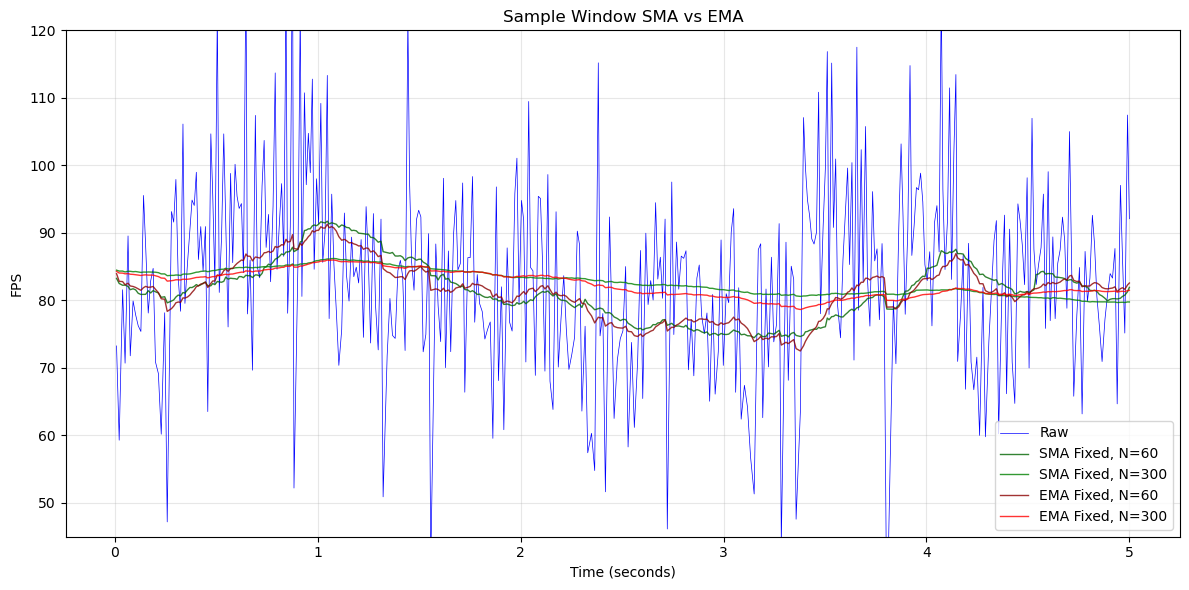

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(times, fps_raw, 'b-', label="Raw", linewidth=0.5)
plt.plot(times, fps_sma_fix_60, 'darkgreen', label="SMA Fixed, N=60", linewidth=1, alpha=0.8)
plt.plot(times, fps_sma_fix_300, 'green', label="SMA Fixed, N=300", linewidth=1, alpha=0.8)
plt.plot(times, fps_ema_fix_60, 'darkred', label="EMA Fixed, N=60", linewidth=1, alpha=0.8)
plt.plot(times, fps_ema_fix_300, 'red', label="EMA Fixed, N=300", linewidth=1, alpha=0.8)
plt.xlabel('Time (seconds)')
plt.ylabel('FPS')
plt.title('Sample Window SMA vs EMA')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.ylim(45, 120)
plt.savefig('sample_fps_graph.png', 
            dpi=300, 
            bbox_inches='tight', 
            transparent=False, 
            facecolor='white',
            edgecolor='none')
plt.show()